# Stock global fits: `lisatools.globalfit.stock`

Run configurations are **installed stock classes**, not settings files. Each
variant is a *configured-but-unbuilt* fit: constructing one is instant and
touches nothing heavy; every block can be inspected and swapped before an
explicit `build()` loads the data, and `run()` drives the whole pipeline.

The building-block pyramid — sub anything in or out at any level:

| level | block | compose with |
|---|---|---|
| atoms | transforms, priors, `MoveSpec`s, injection tables | plain assignment |
| branch | `GBSettings`, `MBHSettings`, ... dataclasses | `fit.gb.<field> = ...`, `fit.gb = MyGBSettings(...)` |
| recipe | `RecipeSpec` = stages of named moves | `fit.recipe.add_move / pop_move / add_stage / pop_stage` |
| fit | branches + general + recipe + setup_function | `fit.add_branch / remove_branch`, `fit.general.<field>` |
| run | `build()` → `CurrentInfoGlobalFit`; `run()` → `GlobalFit` | `fit.build()`, `fit.run(comm=...)` |

This tutorial walks the GB-only variant (`gb_no_fg`) at **smoke scale**
(3-day `Tobs`, 3 walkers × 2 temps, 2 iterations) with the GB debug
instrumentation on, so it runs on a laptop CPU in a few minutes — nothing
here has enough samples to mean anything statistically.

In [1]:
import glob
import os

# Output locations + smoke knobs. Env vars feed the stock defaults
# (explicit kwargs > env var > hard default), so set them BEFORE the
# lisatools import. GB_DEBUG_DIR is where the GB move saves its
# debug figures.
OUT = os.path.abspath("./stock_tutorial_output") + "/"
os.environ["GF_NUM_ITER"] = "2"
os.environ["GB_DEBUG_DIR"] = OUT + "gb_debug/"

from lisatools.globalfit.stock import erebor

erebor.get_stock_options()

cupy not found, using numpy instead. This will be very slow for large runs. Please install cupy and a compatible CUDA version for GPU acceleration.


[('gb_no_fg',
  'GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foreground branch, f in [6, 25] mHz, WDM chunked-het likelihood.'),
 ('all_sources',
  'All six branches (gb, psd, galfor, mbh, emri, sobbh) on the Sangria training data; fixed 90-d WDM grid; legacy MBH/EMRI/SOBBH waveform paths.'),
 ('full_year_combined',
  'Catalogue-driven multi-leaf MBH+EMRI+SOBBH fit over the full year (mojito L1 or synthetic data); fixed noise + annually-modulated foreground; SOBBH TDI-on-the-fly, MBH/EMRI legacy paths.')]

## 1. Get a stock fit (cheap)

`debug=True` applies the fast smoke preset (3-day `Tobs`, tiny chunked-het
kernels, 3 walkers / 2 temps) *and* arms the GB move's debug
instrumentation (band-residual round-trip checks + per-step band figures).
Nothing loads yet — the mojito data path is only a string at this point.

In [2]:
fit = erebor.gb_no_fg(debug=True, file_store_dir=OUT, base_file_name="tutorial")
print(fit.describe())

GBNoForegroundGlobalFit (gb_no_fg) — GB-only fit on the mojito L1 GB galaxy: fixed PSD, no foreground branch, f in [6, 25] mHz, WDM chunked-het likelihood.
  built: False
  headline:
    nwalkers = 3
    ntemps = 2
    dt = 2.5
    num_iterations = 2
    file_store_dir = '/Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/'
    base_file_name = 'tutorial'
    gpus = None
    gpu_backend = 'cuda13x'
    tobs_target = 259200.0
    min_freq = 0.006
    max_freq = 0.025
    tdi_chan = 'XYZ'
    window_tukey_alpha = 0.05
    mojito_data_path = '/Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/'
    use_gpu = None
  branches: ['gb']
    gb: GBNoFgGBSettings
  recipe:
    [pe] gb_pe:
        rj_prior  <- stock branch=gb
  setup_function: setup_recipe


## 2. Adjust knobs

Headline knobs sit on the fit; everything else is plain attribute access on
the blocks (`fit.general`, `fit.gb`, ...). No accessor functions — compose
objects.

In [3]:
# headline knob (delegates to fit.general)
print("nwalkers:", fit.nwalkers, "| ntemps:", fit.ntemps)

# branch-block knobs: the narrow GB band and the in-model repeat count
print("GB band center:", fit.gb.center_freq, "Hz over", fit.gb.n_layers, "WDM layers")
fit.gb.num_repeat_proposals = 2   # smoke speed (a real run wants ~100+)

# derived views recompute from the current knobs
Nf, Nt, wavelet_duration, Tobs = fit.wdm_grid
print(f"WDM grid: Nf={Nf} Nt={Nt} wavelet={wavelet_duration:.0f}s Tobs={Tobs:.3e}s")

nwalkers: 3 | ntemps: 2
GB band center: 0.0075 Hz over 3 WDM layers
WDM grid: Nf=1440 Nt=72 wavelet=3600s Tobs=2.592e+05s


## 3. Edit the recipe (named move stacks per stage)

The recipe is a declarative spec: ordered **stages** (materialized into
`Search/PE/RJRecipeStep`s at build) each holding named **moves**. Pop and
add moves by name with placement control; unknown names error with the
available options.

In [4]:
print(fit.list_moves())

from lisatools.globalfit.stock import MoveSpec

# add the fstat RJ proposal after the prior one, then remove it again
fit.recipe.add_move(MoveSpec("rj_fstat_mcmc", branch="gb"), stage="gb_pe", after="rj_prior")
print("after add:   ", fit.recipe.move_names())
fit.pop_move("rj_fstat_mcmc")
print("after pop:   ", fit.recipe.move_names())

try:
    fit.pop_move("not_a_move")
except KeyError as err:
    print("pop unknown ->", err)

[pe] gb_pe:
    rj_prior  <- stock branch=gb
after add:    ['rj_prior', 'rj_fstat_mcmc']
after pop:    ['rj_prior']
pop unknown -> "Unknown move 'not_a_move'. Available moves: ['rj_prior']."


## 4. Clone / pickle

The pre-build fit is picklable and deep-copyable (sprint rule). Calling the
module default (`erebor.gb_no_fg(...)`) or any instance clones it with
overrides — the original is untouched.

In [5]:
import copy
import pickle

clone = fit(nwalkers=4)                      # fresh copy with an override
print("clone nwalkers:", clone.nwalkers, "| original:", fit.nwalkers)
roundtrip = pickle.loads(pickle.dumps(copy.deepcopy(fit)))
print("pickle round-trip OK:", roundtrip.recipe.move_names())

clone nwalkers: 4 | original: 3
pickle round-trip OK: ['rj_prior']


## 5. Build (the heavy stage, on command)

`build()` loads + pours the mojito GB galaxy onto the WDM grid, constructs
the per-branch `Setup`s (priors, transforms, band structure), and
initializes the `CurrentInfoGlobalFit` layer (the fit **is** one after
this). Requires the mojito L1 cache
(`fit.general.mojito_data_path`).

In [6]:
curr = fit.build()
print("built:", fit.built)
print("branches:", curr.branch_names, "| ndims:", curr.ndims)
gb_info = curr.source_info["gb"]
print(f"GB band edges: {len(gb_info.band_edges)} -> "
      f"[{gb_info.band_edges.min():.4e}, {gb_info.band_edges.max():.4e}] Hz")

2026-07-09 02:31:42,518 - GeneralSetup - DEBUG - Saving h5 backend to /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/tutorial_testing.h5


2026-07-09 02:31:42,518 - GeneralSetup - DEBUG - Saving artifacts to /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/tutorial_artifacts/


2026-07-09 02:31:42,519 - lisatools.globalfit.preprocessing - INFO - L1DataLoader initialized with data folder: /Users/mkatz/.mojito_cache/brickmarket/mojito_light_v1_0_0/data


2026-07-09 02:31:42,520 - lisatools.globalfit.preprocessing - INFO - Source types to load: ['GB']


2026-07-09 02:31:42,520 - lisatools.globalfit.preprocessing - INFO - Source IDs: None


...

2026-07-09 02:32:18,071 - GBSetup - INFO - GB f0 prior range is set from 0.0075 to 0.0076389


2026-07-09 02:32:18,072 - GBSetup - INFO - The number of subbands is 3


2026-07-09 02:32:18,074 - GBSetup - INFO - Min freq of subbands is 0.007361111111111111


2026-07-09 02:32:18,075 - GBSetup - INFO - Max freq of subbands is 0.0077777777777777776


built: True
branches: ['gb'] | ndims: {'gb': 8}
GB band edges: 4 -> [7.3611e-03, 7.7778e-03] Hz


### The input data on the run's WDM grid

In [7]:
import matplotlib.pyplot as plt

wdm_data = curr.general_info.input_data_residual_array.data_res_arr
fig, _ = wdm_data.heatmap(mag=True)
fig.set_size_inches(9, 5)
plt.show()

## 6. Run (one-shot pipeline)

`fit.run()` builds if needed, wraps the fit in `GlobalFit`, and drives the
sampler for `general.num_iterations` iterations (2 here). Production runs
launch under MPI —

```bash
mpiexec -n <ranks> python scripts/run_global.py --stock gb_no_fg
```

— here a single-process stand-in communicator keeps everything in the
notebook.

In [8]:
class NotebookComm:
    """Single-process stand-in for an MPI communicator."""

    def Get_rank(self):
        return 0

    def Get_size(self):
        return 1

    def send(self, *args, **kwargs):
        pass


fit.run(comm=NotebookComm())
print("run complete")

2026-07-09 11:11:55,892 - GlobalFit - DEBUG - need to adjust file path


2026-07-09 11:11:55,896 - GlobalFit - DEBUG - update this somehow


2026-07-09 11:11:55,919 - GlobalFit - DEBUG - state loaded


2026-07-09 11:11:56,149 - lisatools.globalfit.run - WARNING - rebuild_residuals: branch 'gb' has neither a signal_gen entry nor a get_templates hook; skipped.


2026-07-09 11:11:56,152 - lisatools.globalfit.run - INFO - rebuilt residuals from state coords/inds.


...

1it [00:47, 47.01s/it]


100%|██████████| 2/2 [01:37<00:00, 48.41s/it]

100%|██████████| 2/2 [01:37<00:00, 48.69s/it]

2026-07-09 11:14:16,952 - lisatools.globalfit.run - INFO - Residuals saved.


run complete


## 7. Look at the output

Two iterations is nowhere near converged — these plots just show where
everything lives: the sampler chain in the HDF backend, and the run
artifacts directory.

In [9]:
import numpy as np

reader = curr.backend
logl = reader.get_log_like()          # (nsteps, ntemps, nwalkers)
chain = reader.get_chain()["gb"]      # (nsteps, ntemps, nwalkers, nleaves, ndim)
inds = reader.get_inds()["gb"]

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 3.5))
ax0.plot(logl[:, 0], marker="o")
ax0.set_xlabel("iteration"); ax0.set_ylabel("log L (cold chain)")
ax0.set_title(f"{logl.shape[0]} stored iterations")

# every active GB leaf, cold chain: sampled f0 (mHz) vs log10 A
sel = inds[:, 0]
f0 = chain[:, 0][sel][:, 1]
logA = chain[:, 0][sel][:, 0] / np.log(10.0)
ax1.scatter(f0, logA, s=12, alpha=0.7)
ax1.set_xlabel("f0 [mHz]"); ax1.set_ylabel("log10 A")
ax1.set_title(f"{sel.sum()} active-leaf samples")
plt.tight_layout(); plt.show()

### GB debug figures

With the debug instrumentation armed, the GB move saves band figures for
one traced `(walker, band)` cell — a panel per temperature at the
begin/middle/end of each proposal block, plus per-source sequence figures.
They are the fastest way to see whether the sampler is doing something
sane: the total template (line) should track the data (dots) in the traced
band.

12 debug figures under /Users/mkatz/Research/lisa_sprint_2026/LISAanalysistools/examples/stock_tutorial_output/gb_debug/
   gb_debug/gb_debug_inmodel_band1_w0_move0_0001.png
   gb_debug/gb_debug_inmodel_band1_w0_move0_0007.png
   gb_debug/gb_debug_rj_band1_w0_move0_0000.png
   gb_debug/gb_debug_rj_band1_w0_move0_0006.png
   gb_debug/gb_debug_seq1_before_removal_band1_w0_t1_0002.png
   gb_debug/gb_debug_seq1_before_removal_band1_w0_t1_0008.png
   gb_debug/gb_debug_seq2_after_removal_band1_w0_t1_0003.png
   gb_debug/gb_debug_seq2_after_removal_band1_w0_t1_0009.png
   gb_debug/gb_debug_seq3_before_addback_band1_w0_t1_0004.png
   gb_debug/gb_debug_seq3_before_addback_band1_w0_t1_0010.png
   gb_debug/gb_debug_seq4_after_addback_band1_w0_t1_0005.png
   gb_debug/gb_debug_seq4_after_addback_band1_w0_t1_0011.png
gb_debug/gb_debug_inmodel_band1_w0_move0_0001.png


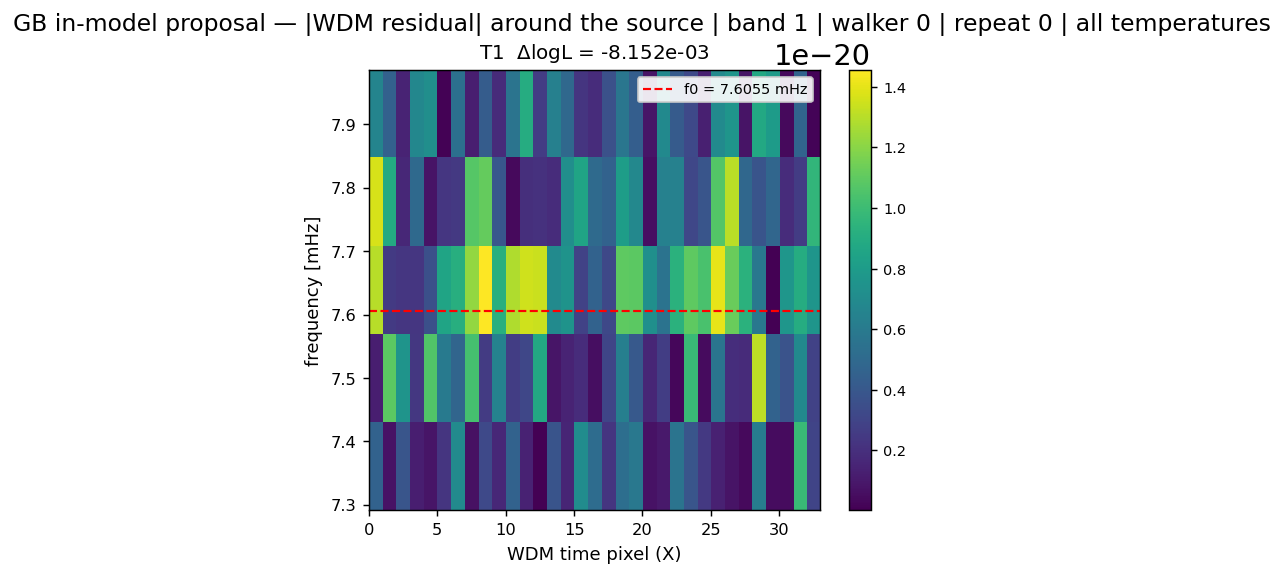

gb_debug/gb_debug_inmodel_band1_w0_move0_0007.png


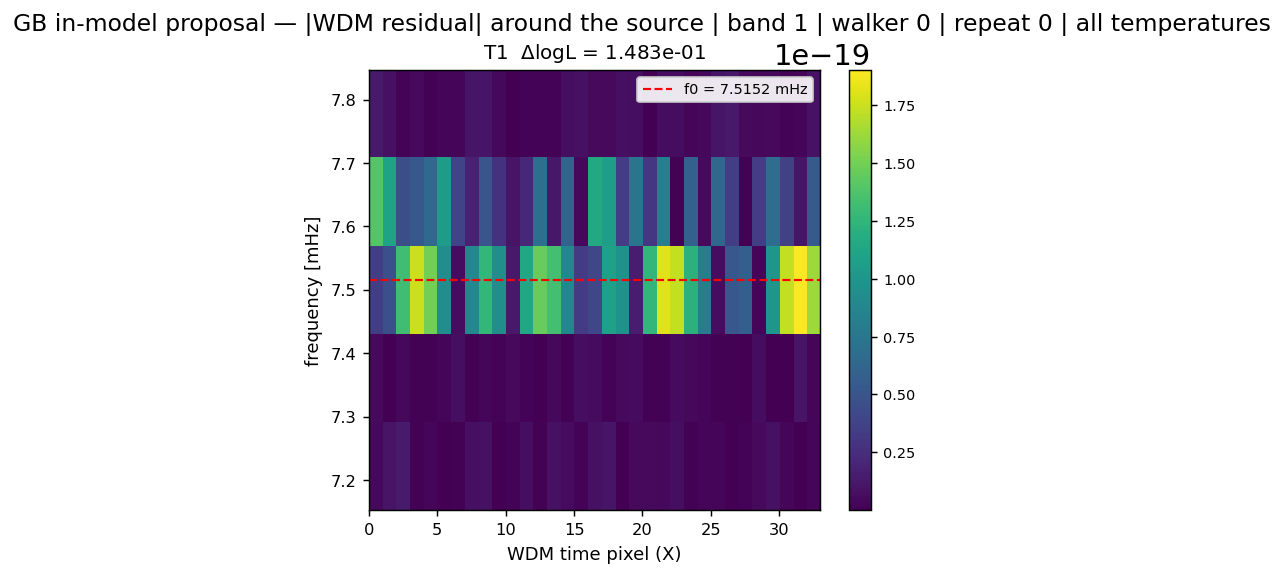

gb_debug/gb_debug_rj_band1_w0_move0_0000.png


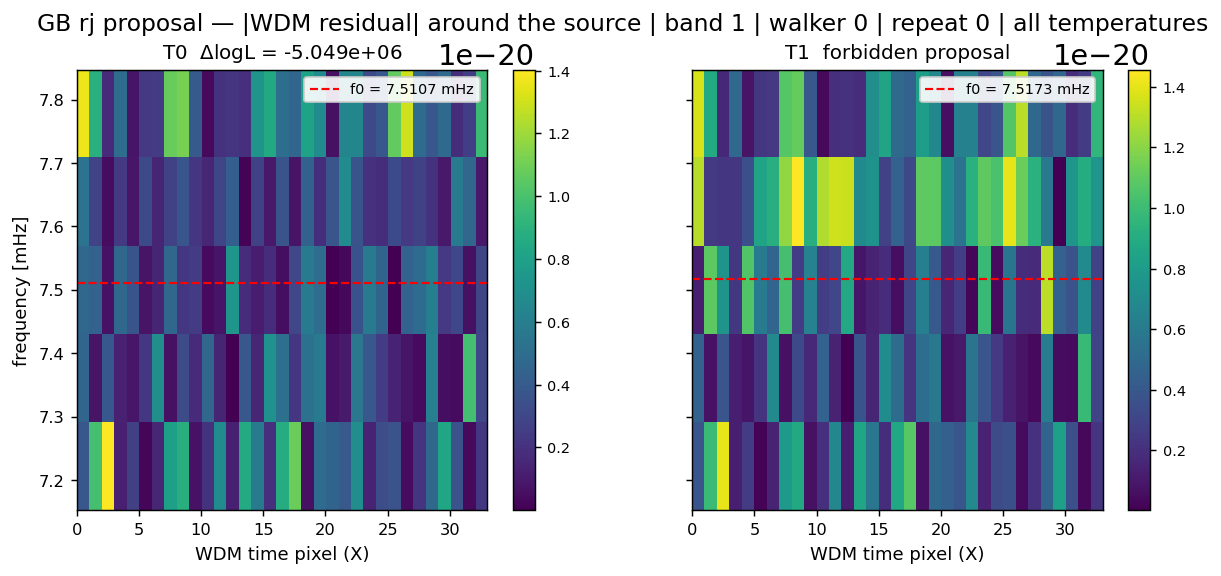

gb_debug/gb_debug_rj_band1_w0_move0_0006.png


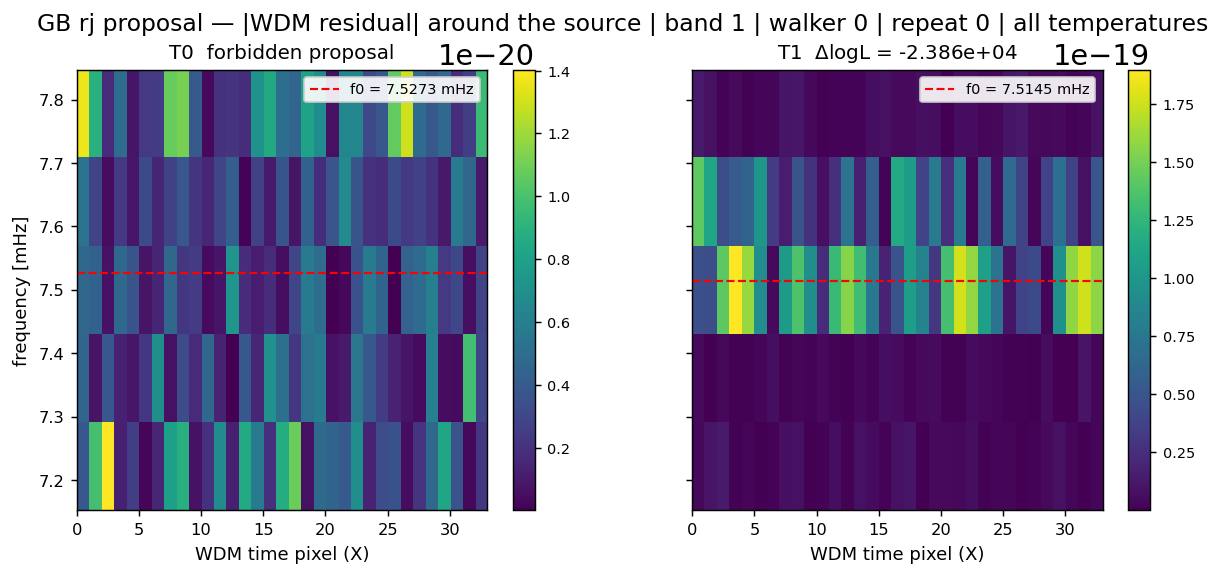

In [10]:
debug_pngs = sorted(glob.glob(OUT + "gb_debug/**/*.png", recursive=True))
print(f"{len(debug_pngs)} debug figures under {OUT}gb_debug/")
for p in debug_pngs:
    print("  ", os.path.relpath(p, OUT))

from IPython.display import Image, display

for p in debug_pngs[:4]:
    print(os.path.relpath(p, OUT))
    display(Image(filename=p, width=900))

## Where to go from here

- **Other stock variants**: `erebor.all_sources` (six branches on Sangria
  data) and `erebor.full_year_combined` (catalogue-driven multi-leaf
  MBH+EMRI+SOBBH; per-branch `use_tdionfly` waveform-path knobs).
- **Whole-object swaps**: `fit.general.domain_settings =
  FDSettings.make_factory(...)`, `fit.general.data_processor_class = ...`,
  `fit.setup_function = my_recipe`, `fit.add_branch("psd", PSDSettings(...))`.
- **New variants**: subclass `EreborFit` in
  `lisatools/globalfit/stock/erebor/variants/` and register it — knobs are
  documented dataclass fields. Per the sprint rule there are **no new
  settings files**; the `global_fit_input/*.py` paths are compatibility
  stubs.